# 08 Implied volatility

Historical volatility, which we found in notebook 6, looks backwards to measure how volatile the stock has been. Conversely, implied volatility looks forward to see how volatile the market is going to be.
Given a market option price, implied volatility is the $\sigma$ that makes the Black-Scholes formula reproduce that price, and is the market's consensus forecast of future volatility.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime
from pricer import bs_pricing, implied_volatility

## Verify on a known price

Before running on real data, we check that the IV calculation is correct.
If we feed the Black-Scholes price back in, we should recover the
original $\sigma$ exactly.

In [2]:
Sof0  = 100
K     = 105
r     = 0.05
sigma = 0.20
T     = 1.0

# compute BS price at known vol
bs_price = bs_pricing(Sof0, K, r, sigma, T, option_type='call')

# recover vol from that price
iv = implied_volatility(bs_price, Sof0, K, r, T, option_type='call')

print(f"Input sigma        : {sigma:.10f}")
print(f"Black-Scholes price: ${bs_price:.2f}")
print(f"Recovered IV       : {iv:.10f}")
print(f"Difference         : {abs(sigma - iv):.2e}")

Input sigma        : 0.2000000000
Black-Scholes price: $8.02
Recovered IV       : 0.2000000013
Difference         : 1.31e-09


## Pull real options data

We compute implied volatility for every strike in a real AAPL
options chain and plot the volatility smile.

In [3]:
ticker = yf.Ticker("AAPL")
hist   = ticker.history(period="1y")
hist.index = hist.index.tz_localize(None)
Sof0   = hist['Close'].iloc[-1]

# pick expiry
expiry      = ticker.options[4]
expiry_date = datetime.strptime(expiry, "%Y-%m-%d")
T           = (expiry_date - datetime.today()).days / 365

chain = ticker.option_chain(expiry)
calls = chain.calls.copy()
puts  = chain.puts.copy()

print(f"AAPL current price : ${Sof0:.2f}")
print(f"Expiry             : {expiry}  ({T*365:.0f} days)")

AAPL current price : $254.23
Expiry             : 2026-03-27  (9 days)


In [4]:
# clean and filter
def clean_chain(df, Sof0):
    df = df[df['volume'] > 0].copy()
    df = df[(df['strike'] > Sof0 * 0.7) &
            (df['strike'] < Sof0 * 1.3)].copy()
    df['mid_price'] = (df['bid'] + df['ask']) / 2
    df = df[df['mid_price'] > 0.10].copy()
    return df

calls = clean_chain(calls, Sof0)
puts  = clean_chain(puts,  Sof0)

print(f"Call strikes: {len(calls)}  |  Put strikes: {len(puts)}")

Call strikes: 29  |  Put strikes: 35


KeyError: 'our_iv'

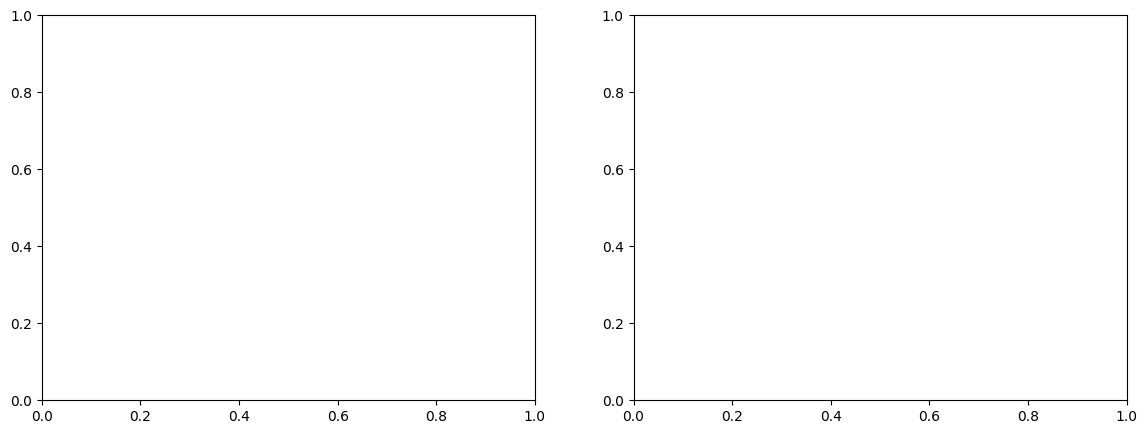

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot 1: our IV vs yahoo's IV (sanity check)
axes[0].scatter(calls['strike'], calls['our_iv'],
                color='steelblue', s=20, label='Our IV (calls)')
axes[0].scatter(calls['strike'], calls['impliedVolatility'],
                color='coral', s=20, marker='x', label="Yahoo IV (calls)")
axes[0].axvline(Sof0, color='gray', linestyle='--',
                linewidth=0.8, label=f'S₀ = ${Sof0:.0f}')
axes[0].set_xlabel('Strike ($)')
axes[0].set_ylabel('Implied volatility')
axes[0].set_title('Our IV vs Yahoo Finance IV')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].legend(fontsize=8)

# plot 2: volatility smile — calls and puts
axes[1].plot(calls['strike'], calls['our_iv'],
             color='steelblue', linewidth=1.2, marker='o',
             markersize=3, label='Calls')
axes[1].plot(puts['strike'], puts['our_iv'],
             color='coral', linewidth=1.2, marker='o',
             markersize=3, label='Puts')
axes[1].axvline(Sof0, color='gray', linestyle='--',
                linewidth=0.8, label=f'S₀ = ${Sof0:.0f}')
axes[1].set_xlabel('Strike ($)')
axes[1].set_ylabel('Implied volatility')
axes[1].set_title(f'Volatility smile — AAPL {expiry}')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()